In [1]:
# taken from Hamish's code and modified 

import numpy as np
import sympy as sp
from scipy import integrate 
import scipy
import math
import matplotlib.pyplot as plt
import cmath


points=1000

def meanEOM(t, U, mu):
    """
    This function defines the real equations of motion as per equation 7 and 8 of the paper

    Takes in an np.linspace as t
    an initial guess as U - must be an array with [theta=0,phi=0]
    mu is a real number that parameterises the interaction strength

    It outputs an array of [thetadot,phidot] which is the derivatives of theta and phi at the given point t, but obvs if u feed in the linspace, it
    becomes a list of all these points in an array.
    """
    
    #U is gonna be the theta and phi stored as a []
    theta, phi = U

    #then define the functions
    thetadot = -1*np.sin(phi)
    phidot = np.tan(theta)*np.cos(phi)+mu*np.sin(theta)
    
    return [thetadot, phidot]

#this is the one from the inline eq below eq 8
def meanTraj_thetaphi(points, U_0, time_domain, mu):
    """
    This function takes in the theta coordinate found in the previous function, and outputs the expectation value of the number operator as t changes
    but t changing is built in to the solution of theta from the prev function
    """

    #this one is confusing so ill explain it
    sol = scipy.integrate.solve_ivp(meanEOM, (0,points), U_0, t_eval = time_domain, args = (mu,),method='LSODA')

    theta=sol.y[0]
    phi=sol.y[1]
    """
        realEOM is the function we are integrating - see above
        (0,points) is the number of points we integrate over
        U_0 is the initial guess, time_domain is the t linspace as per,
        and args takes in any arguments other than the t linspace and initial guess U_0 that need to be passed to the function (realEOM)
        in this case realEOM takes mu as an arg, so we pass it mu
        the .y at the end gives the solution, where each row of the .y corresponds to a variable (in this case theta or phi)
    """
    return theta,phi

def meanTraj_LR(points, U_0, time_domain, mu):
    """
    Use phi=phiR-phiL so basically calculating exp(-i phiL)L and exp(-i phiL)R so that end up with no phase term on the L 
    and the phase term with phi on R
    """
    theta, phi = meanTraj_thetaphi(points, U_0, time_domain, mu)
    
    L=np.sqrt( (1+np.sin(theta))/2 )
    R=np.sqrt( (1-np.sin(theta))/2 )*np.exp(1j*phi)
    return L,R


def state(points, U_0, t_list, mu):
    (L,R)=meanTraj_LR(points, U_0, t_list, mu)
    L=np.array(L)
    R=np.array(R)

    state=np.array([L*L,L*R,L*R,R*R])
    return state

In [2]:
#Real EOM

#initial conditions
U_0 = [np.pi/2,0] # this gives LL initially

#this is just so that when we store it we only store values at these points on the linspace, not everything - necessary for the plots but not in general
points = 1000
time_domain = np.linspace(0,20,points)
mu=4

(L,R)=meanTraj_LR(points, U_0, time_domain, mu)

# plt.plot(time_domain, L.real, "-", label="L")
# plt.plot(time_domain, L.imag, "-", label="L imag")
# plt.plot(time_domain, R.real, "-", label="R")
# plt.plot(time_domain, R.imag, "-", label="R imag")
# plt.legend()
# plt.show()

# plt.plot(time_domain, np.abs(L)**2, "-", label="L")
# plt.plot(time_domain, np.abs(R)**2, "-", label="R")
# plt.legend()
# plt.show()

state=state(points, U_0, time_domain, mu)
print(state.shape)
print(np.array(L).shape)

(4, 1000)
(1000,)


(4, 1000)


C:\Users\annas\anaconda3\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\annas\anaconda3\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


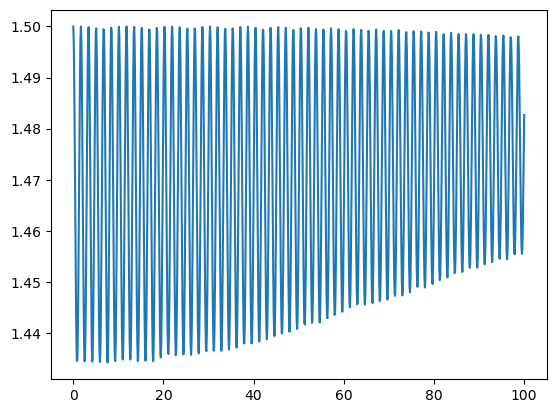

In [28]:
a=1
mu_list=np.array([4])
points=1000
t_list=np.linspace(0,100,points)
U_0 = [np.pi/2,0] # this gives LL initially

psi=state(points, U_0, t_list, mu_list[0]) # basis LL LR RL RR
print(psi.shape)
plt.plot(t_list,psi[0,:])
plt.show()